# U.S. total gasoline supply, demand, and stocks
## An auditable comparison of monthly PADD models

**Question:** Can gasoline supply-and-demand history predict next month's ending stocks better than simply carrying the latest stock level forward?

We build one model for each of the five Petroleum Administration for Defense Districts (PADDs), then sum their predictions. We compare **11 approaches**, choose on **10 expanding time-series folds**, and evaluate on a **separate final 24-month holdout**. We also produce and backtest recursive 12-month supply, demand, balance, and stock paths.

**Scope:** The modeled product is **total motor gasoline: finished motor gasoline plus motor gasoline blending components**. The target is the independently published EIA total stock series (`MGTSTP`). Supply and disposition combine both product balances, including blending-component refinery/blender net inputs. This notebook does not predict RBOB prices.

Read in order: data and definitions → historical balance → forecast timing → candidate models → validation → holdout results → 12-month outlook → limitations and reproducibility.

**Everything needed to understand the work is below:** source handling, all eleven candidate model definitions, a worked validation example, the complete experiment in six visible stages, diagnostics, conclusions, and checks. No project `.py` imports or companion notebooks are needed. Run All uses the accompanying `data/` snapshots; all result tables and figures are already saved in this notebook.

### Reading guide

1. **Understand the inputs:** Sections 1–2 explain series definitions, missing values, the finished/total gasoline distinction, and accounting checks.
2. **Understand the models:** Sections 3–4 show exactly how a forecast row and each candidate are built.
3. **Follow the experiment:** Section 5 runs the full validation and forecast workflow step by step.
4. **Read the evidence:** Sections 6–10 compare results and expose where the models fail.
5. **Reproduce and check:** Section 11 contains the conclusions and integrity checks.

Code cells define the actual functions used below; they are not pseudocode. You can read the prose and saved outputs first, then inspect each implementation in place.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
from concurrent.futures import ThreadPoolExecutor
import hashlib, io, json, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, duckdb, joblib, sklearn, xgboost
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from IPython.display import display, Markdown

# Only input data are external. No local Python module is imported.
HERE=Path.cwd()
if not (HERE/'data/eia_observations.csv').exists():
    HERE=HERE/'oil'/'us_snd_gasoline'
assert (HERE/'data/eia_observations.csv').exists(), 'Keep the data folder beside this notebook.'
DATABASE=HERE.parents[1]/'data/commodities.duckdb'  # optional JODI refresh only
OUTPUT=HERE/'model_output'
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format',lambda x:f'{x:,.2f}')

## 1. Sources, units, and product boundary

EIA publishes month-end stocks and calendar-month supply/disposition volumes. Everything in the model is measured in **thousand barrels (kb)**; charts use **million barrels (kb / 1,000)**. Product supplied is a consumption proxy derived from the petroleum balance, not an independent measure of retail sales. For the total gasoline boundary, net refinery/blender production equals finished gasoline net production **minus blending-component refinery/blender net inputs**. This offsets internal conversion into finished gasoline instead of counting it as new total gasoline supply.

Source references: [EIA balance definitions](https://www.eia.gov/dnav/pet/TblDefs/pet_sum_snd_tbldef2.asp), [PADD 1 balance table](https://www.eia.gov/dnav/pet/pet_sum_snd_d_r10_mbbl_m_cur.htm), and [total motor gasoline definition](https://www.eia.gov/dnav/pet/TblDefs/pet_sum_sndw_tbldef2.asp).

The source manifest contains 95 product/region records: 93 EIA spreadsheets and two balance-page snapshots documenting no published blending-component biofuel-production series in PADDs 3 and 4. Those two inputs use flagged structural zeros. Original XLS files, series titles, URLs, retrieval timestamps, and SHA-256 hashes are preserved under `data/`. The model uses history from January 2007. This matches the crude archive's starting period and avoids fitting across still earlier reporting regimes.

No-data-reported or absent cells in sparse imports, exports, net receipts, and biofuel series are **assumed zero and flagged**. Withheld/unavailable text markers are not replaced. Core missing observations cause an error. The balance reconciliation below checks whether those assumptions are consistent with reported totals. A common complete endpoint is required across all five PADDs.

### Series map and input preparation

This is the exact EIA code map and sign convention. `load_panel` reshapes source observations into a complete monthly PADD panel, retains zero assumptions, retains finished and total gasoline stock scope, and calculates historical balance residuals.

In [2]:
PADD_NAMES = {1: 'East Coast', 2: 'Midwest', 3: 'Gulf Coast', 4: 'Rocky Mountain', 5: 'West Coast'}
# Total motor gasoline = finished motor gasoline + motor gasoline blending components.
# Preserve each constituent series; derive total net production by subtracting
# blending-component refinery/blender NET inputs from finished net production.
FINISHED_CODES = {'production_kb': 'MGFRPP{p}1', 'demand_kb': 'MGFUPP{p}1',
    'imports_kb': 'MGFIMP{p}1', 'exports_kb': 'MGFEXP{p}1',
    'net_receipts_kb': 'MGFNRP{p}1', 'adjustments_kb': 'MGFUA_R{p}0_1',
    'biofuels_kb': 'M_EPM0F_YNP_R{p}0_MBBL',
    'stock_kb': 'MGFSTP{p}1', 'reported_stock_change_kb': 'MGFSCP{p}1'}
BLENDING_CODES = {'net_inputs_kb': 'MBCRIP{p}1', 'demand_kb': 'MBCUPP{p}1',
    'imports_kb': 'MBCIMP{p}1', 'exports_kb': 'MBCEXP{p}1',
    'net_receipts_kb': 'MBCNRP{p}1', 'adjustments_kb': 'MBCUA_R{p}0_1',
    'biofuels_kb': 'M_EPOBG_YNP_R{p}0_MBBL',
    'stock_kb': 'MBCSTP{p}1', 'reported_stock_change_kb': 'MBCSCP{p}1'}
CODES = {**{'finished_' + c: v for c,v in FINISHED_CODES.items()},
         **{'blending_' + c: v for c,v in BLENDING_CODES.items()},
         'stock_kb': 'MGTSTP{p}1'}
FLOWS = ['production_kb', 'demand_kb', 'imports_kb', 'exports_kb',
         'net_receipts_kb', 'adjustments_kb', 'biofuels_kb']
SIGNS = [1, -1, 1, -1, 1, 1, 1]
SPARSE = {prefix + c for prefix in ['finished_', 'blending_']
          for c in ['imports_kb', 'exports_kb', 'biofuels_kb', 'net_receipts_kb']}

In [3]:
def load_panel(data_dir=HERE / 'data', start='2007-01-01'):
    raw = pd.read_csv(Path(data_dir) / 'eia_observations.csv', parse_dates=['month'])
    if raw.duplicated(['month', 'padd', 'component']).any():
        raise ValueError('Duplicate EIA observations')
    panels = []
    for p in PADD_NAMES:
        r = raw[raw.padd.eq(p)]
        end = r[r.component.eq('stock_kb') & r.value.notna()].month.max()
        index = pd.date_range(start, end, freq='MS')
        wide = r.pivot(index='month', columns='component', values='value').reindex(index)
        for c in sorted(SPARSE):
            rows = r[r.component.eq(c)].set_index('month')
            # Missing calendar rows in sparse trade/biofuel sheets are an explicit
            # no-reported-flow assumption, not interpolation from future values.
            absent = ~wide.index.isin(rows.index)
            wide[c + '_assumed_zero'] = rows.assumed_zero.reindex(index).astype("boolean").fillna(False).astype(bool) | absent
            wide.loc[absent, c] = 0.0
        wide['padd'] = p
        wide['padd_name'] = PADD_NAMES[p]
        wide.index.name = 'month'
        panels.append(wide.reset_index())
    panel = pd.concat(panels, ignore_index=True)
    core = list(CODES)
    valid = panel[core].notna().all(axis=1)
    common = panel[valid].groupby('month').padd.nunique()
    end = common[common.eq(5)].index.max()
    panel = panel[panel.month.le(end)].copy()
    if panel[core].isna().any().any():
        raise ValueError('Unresolved missing core data; inspect the source snapshots')
    if not panel.groupby('padd').size().eq(len(pd.date_range(start, end, freq='MS'))).all():
        raise ValueError('Incomplete PADD calendar')
    # Boundary reconciliation: internal blending inputs offset finished output.
    panel['production_kb'] = panel.finished_production_kb - panel.blending_net_inputs_kb
    for c in FLOWS[1:] + ['reported_stock_change_kb']:
        panel[c] = panel['finished_' + c] + panel['blending_' + c]
    panel['stock_component_residual_kb'] = panel.stock_kb - panel.finished_stock_kb - panel.blending_stock_kb
    if panel.stock_component_residual_kb.abs().max() > 1:
        raise ValueError('Published total gasoline stocks do not match the two constituent stocks')
    panel['total_gasoline_stock_kb'] = panel.stock_kb  # explicit compatibility alias
    panel['previous_stock_kb'] = panel.groupby('padd').stock_kb.shift(1)
    panel['balance_kb'] = panel[FLOWS].to_numpy() @ SIGNS
    panel['stock_change_kb'] = panel.stock_kb - panel.previous_stock_kb
    panel['accounting_residual_kb'] = panel.stock_change_kb - panel.balance_kb
    panel['reported_change_residual_kb'] = panel.stock_change_kb - panel.reported_stock_change_kb
    return panel

### Optional data collection, included for completeness

The downloader below preserves the XLS source bytes and their hashes, normalizes EIA observations, and snapshots JODI from DuckDB. It is defined here but **not called** during the normal offline run. Set `REFRESH_SOURCES=True` only when you want fresh EIA data and have the local JODI database available. Changing the snapshot may change dates and results.

In [4]:
def refresh_data(data_dir=HERE / 'data', database=DATABASE):
    data_dir = Path(data_dir)
    raw_dir = data_dir / 'raw'
    raw_dir.mkdir(parents=True, exist_ok=True)
    def download(task):
        p, component, code = task
        if component == 'blending_biofuels_kb' and p in [3, 4]:
            # EIA's balance page has no biofuel-production series for this
            # product/region. Archive that page and flag the zero convention.
            url = f'https://www.eia.gov/dnav/pet/pet_sum_snd_d_r{p}0_mbbl_m_cur.htm'
            response = requests.get(url, timeout=60)
            response.raise_for_status()
            if 'Motor Gasoline Blend. Comp.' not in response.text or code in response.text:
                raise ValueError(f'Review structural-zero policy for {code}')
            filename = f'blending_biofuels_padd{p}_source.html'
            (raw_dir / filename).write_bytes(response.content)
            months = pd.date_range('1981-01-01', pd.Timestamp.now(), freq='MS')
            frame = pd.DataFrame({'month': months, 'padd': p, 'component': component,
                'value': 0.0, 'assumed_zero': True, 'series_id': code})
            return frame, {'padd': p, 'component': component, 'series_id': code,
                'url': url, 'title': 'No published blending-component biofuel production series; assumed zero',
                'source_file': filename, 'kind': 'structural_zero',
                'sha256': hashlib.sha256(response.content).hexdigest(),
                'retrieved_utc': datetime.now(timezone.utc).isoformat(), 'rows': len(frame)}
        url = f'https://www.eia.gov/dnav/pet/hist_xls/{code}m.xls'
        response = requests.get(url, timeout=60)
        response.raise_for_status()
        content = response.content
        table = pd.read_excel(io.BytesIO(content), sheet_name='Data 1', header=2, keep_default_na=False)
        if table.shape[1] != 2 or 'Thousand Barrels' not in str(table.columns[1]):
            raise ValueError(f'Unexpected units/schema: {code}')
        (raw_dir / f'{code}m.xls').write_bytes(content)
        original = table.iloc[:, 1]
        values = pd.to_numeric(original, errors='coerce')
        # Excel empty cells correspond to no-data-reported on these sparse series.
        # Preserve text markers so W/NA cannot silently turn into zero.
        empty = original.isna() | original.astype(str).str.strip().isin(['', '-'])
        zero = values.isna() & empty & (component in SPARSE)
        values = values.mask(zero, 0.0)
        frame = pd.DataFrame({'month': pd.to_datetime(table.iloc[:, 0]).dt.to_period('M').dt.to_timestamp(),
            'padd': p, 'component': component, 'value': values, 'assumed_zero': zero, 'series_id': code})
        # Sparse worksheets sometimes stop before the common archive endpoint;
        # calendar extension is handled explicitly by load_panel, with flags.
        meta = {'padd': p, 'component': component, 'series_id': code, 'url': url,
                'source_file': f'{code}m.xls', 'kind': 'observed_series',
                'title': str(table.columns[1]), 'sha256': hashlib.sha256(content).hexdigest(),
                'retrieved_utc': datetime.now(timezone.utc).isoformat(), 'rows': len(frame)}
        return frame, meta
    tasks = [(p, c, template.format(p=p)) for p in PADD_NAMES for c, template in CODES.items()]
    with ThreadPoolExecutor(max_workers=6) as pool:
        results = list(pool.map(download, tasks))
    raw = pd.concat([r[0] for r in results], ignore_index=True)
    raw.to_csv(data_dir / 'eia_observations.csv', index=False)
    (data_dir / 'source_manifest.json').write_text(json.dumps([r[1] for r in results], indent=2))
    with duckdb.connect(str(database), read_only=True) as con:
        jodi = con.execute("""SELECT time_period, flow_breakdown, obs_value, assessment_code
            FROM fundamental.jodi_observation WHERE ref_area='US'
            AND energy_product='GASOLINE' AND unit_measure='KBBL'""").fetchdf()
    jodi.to_csv(data_dir / 'jodi_us_raw.csv', index=False)
    (data_dir / 'jodi_source.json').write_text(json.dumps({'database': str(database),
        'table': 'fundamental.jodi_observation', 'product': 'GASOLINE', 'unit': 'KBBL',
        'snapshot_utc': datetime.now(timezone.utc).isoformat()}, indent=2))
    return load_panel(data_dir)

In [5]:
REFRESH_SOURCES = False
if REFRESH_SOURCES:
    refresh_data(HERE/'data', database=DATABASE)

In [6]:
manifest = pd.read_json(HERE / 'data/source_manifest.json')
display(manifest[manifest.padd.eq(1)][['component','series_id','title','url']])
panel = load_panel(HERE / 'data')
display(panel.groupby('padd').agg(start=('month','min'), end=('month','max'), months=('month','size')))
flags = [c for c in panel if c.endswith('_assumed_zero')]
display(panel.groupby('padd')[flags].sum().rename_axis('PADD: count of assumed-zero months'))

,component,series_id,title,url
0,finished_production_kb,MGFRPP11,East Coast (PADD 1) Refinery and Blender Net P...,https://www.eia.gov/dnav/pet/hist_xls/MGFRPP11...
1,finished_demand_kb,MGFUPP11,East Coast (PADD 1) Product Supplied of Finish...,https://www.eia.gov/dnav/pet/hist_xls/MGFUPP11...
2,finished_imports_kb,MGFIMP11,East Coast (PADD 1) Imports of Finished Motor ...,https://www.eia.gov/dnav/pet/hist_xls/MGFIMP11...
3,finished_exports_kb,MGFEXP11,East Coast (PADD 1) Exports of Finished Motor ...,https://www.eia.gov/dnav/pet/hist_xls/MGFEXP11...
4,finished_net_receipts_kb,MGFNRP11,"East Coast (PADD 1) Net Receipts by Pipeline, ...",https://www.eia.gov/dnav/pet/hist_xls/MGFNRP11...
5,finished_adjustments_kb,MGFUA_R10_1,East Coast (PADD 1) Supply Adjustment of Finis...,https://www.eia.gov/dnav/pet/hist_xls/MGFUA_R1...
6,finished_biofuels_kb,M_EPM0F_YNP_R10_MBBL,East Coast (PADD 1) Biofuels Plant Net Product...,https://www.eia.gov/dnav/pet/hist_xls/M_EPM0F_...
7,finished_stock_kb,MGFSTP11,East Coast (PADD 1) Ending Stocks of Finished ...,https://www.eia.gov/dnav/pet/hist_xls/MGFSTP11...
8,finished_reported_stock_change_kb,MGFSCP11,East Coast (PADD 1) Finished Motor Gasoline St...,https://www.eia.gov/dnav/pet/hist_xls/MGFSCP11...
9,blending_net_inputs_kb,MBCRIP11,East Coast (PADD 1) Refinery and Blender Net I...,https://www.eia.gov/dnav/pet/hist_xls/MBCRIP11...


,start,end,months
padd,,,
1,2007-01-01,2026-06-01,234
2,2007-01-01,2026-06-01,234
3,2007-01-01,2026-06-01,234
4,2007-01-01,2026-06-01,234
5,2007-01-01,2026-06-01,234


component,blending_biofuels_kb_assumed_zero,blending_exports_kb_assumed_zero,blending_imports_kb_assumed_zero,blending_net_receipts_kb_assumed_zero,finished_biofuels_kb_assumed_zero,finished_exports_kb_assumed_zero,finished_imports_kb_assumed_zero,finished_net_receipts_kb_assumed_zero
PADD: count of assumed-zero months,,,,,,,,
1,116,0,0,0,230,0,0,0
2,38,4,28,0,24,3,151,0
3,234,0,2,0,180,0,109,0
4,234,142,90,10,230,65,219,0
5,190,0,2,2,174,0,2,0


## 2. Reconstruct the historical balance first

For each PADD and month:

\[
S_t = S_{t-1} + P_t + I_t + N_t + A_t + B_t - D_t - X_t + \epsilon_t
\]

| Symbol | Meaning |
|---|---|
| S | Ending total gasoline stocks (finished + blending components) |
| P | Finished refinery/blender net production minus blending-component refinery/blender net inputs |
| I / X | Imports / exports |
| N | Net receipts from other PADDs; may be negative |
| A | EIA supply adjustments; may be negative |
| B | Biofuel plant net production summed across finished gasoline and blending components |
| D | Product supplied summed across both product categories |
| ε | Remaining accounting/reporting difference |

Flows in month **t** reconcile the change from **t−1 to t**. This corrects the timing of the earlier crude implementation for this new model. The crude model itself has only been relocated.

A near-exact reconstruction is an accounting check, **not forecast accuracy**: product supplied already incorporates stock change in EIA's calculation. Consequently, actual target-month flows are never used to forecast that month's stocks.

,maximum_balance_residual_kb,maximum_reported_change_difference_kb
padd,,
1,66.00,66.00
2,4.00,5.00
3,43.00,43.00
4,1.00,0.00
5,81.00,81.00


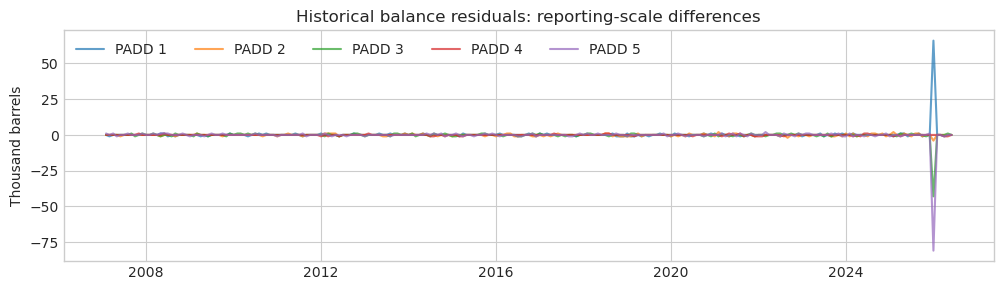

In [7]:
checks = panel.groupby('padd').agg(
    maximum_balance_residual_kb=('accounting_residual_kb', lambda s: s.abs().max()),
    maximum_reported_change_difference_kb=('reported_change_residual_kb', lambda s: s.abs().max()))
display(checks)
assert checks.maximum_balance_residual_kb.max() <= 81
fig, ax = plt.subplots(figsize=(12,3))
for p, g in panel.groupby('padd'):
    ax.plot(g.month, g.accounting_residual_kb, label=f'PADD {p}', alpha=.7)
ax.set(title='Historical balance residuals: reporting-scale differences', ylabel='Thousand barrels')
ax.legend(ncol=5); plt.show()

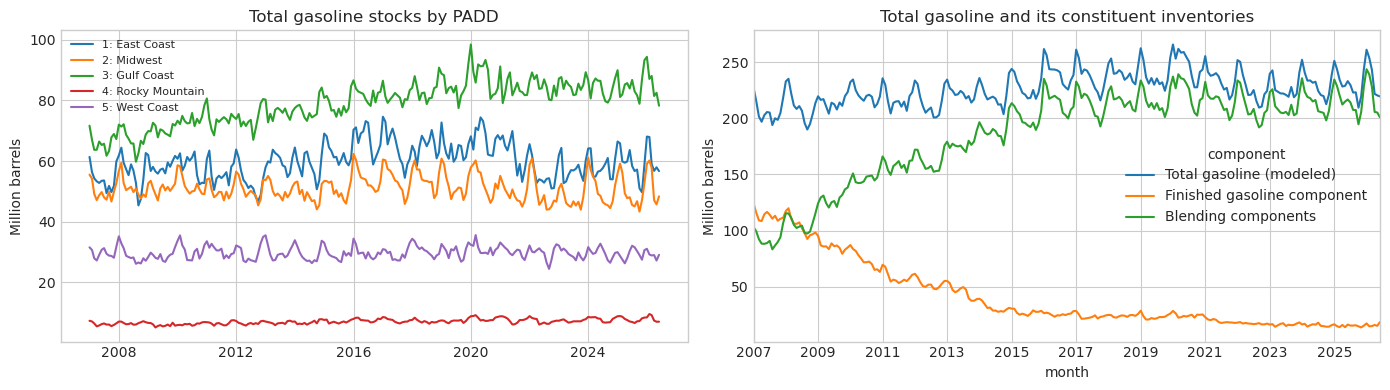

In [8]:
fig, axes = plt.subplots(1,2,figsize=(14,4))
for p,g in panel.groupby('padd'):
    axes[0].plot(g.month, g.stock_kb/1000, label=f'{p}: {PADD_NAMES[p]}')
context = panel.groupby('month')[['stock_kb','finished_stock_kb','blending_stock_kb']].sum()
(context/1000).rename(columns={'stock_kb':'Total gasoline (modeled)',
    'finished_stock_kb':'Finished gasoline component', 'blending_stock_kb':'Blending components'}).plot(ax=axes[1])
axes[0].set_title('Total gasoline stocks by PADD'); axes[0].legend(fontsize=8)
axes[1].set_title('Total gasoline and its constituent inventories')
for ax in axes: ax.set_ylabel('Million barrels')
plt.tight_layout(); plt.show()

The total stock series matches the sum of finished and blending-component stocks within 1 kb. January 2026 has reported-stock-change versus stock-level discrepancies of +66, -43, and -81 kb in PADDs 1, 3, and 5 respectively; these source differences remain visible. The historical stock levels change substantially over time. A model can obtain a high stock-level R² by following this slow movement while still doing poorly on monthly changes. We therefore select on MAE and compare with persistence, inspect annual folds, and report a recent untouched holdout.

## 3. What information does a forecast use?

Each row predicts stock in month **t**, using observed stocks and flows only through **t−1**, plus the known calendar month of t. Features include the last stock, the same month's stock a year earlier, the latest stock change, signed lagged flows, and sine/cosine month terms.

This is a **conditional monthly forecast**, not a real-time vintage backtest. EIA publishes monthly data with a delay and later revises it. The experiment assumes prior-month observations are available; it does not claim that all features were available at the start of each calendar month. July and August 2026 outlook rows are projections beyond June's observed data, even though those calendar months have passed at the time of preparation.

The flow-accounting baseline separately forecasts every target-month flow using only earlier observations: the last 60 months of **daily rates**, a linear trend, and month fixed effects. Rates are multiplied by target-month days. Trade and demand forecasts have a zero floor; net refinery production, adjustments, receipts, and biofuel net production retain their signs. In particular, blending-component net inputs may be negative, indicating net production of blendstocks.

### Build a forecast row from past observations

`forecast_flows` converts monthly volumes to daily rates, fits trend and calendar effects on earlier observations, then converts forecasts back to monthly volumes. `feature_row` reads only the supplied history. `supervised` stops that history immediately before each target month and attaches the target separately.

In [9]:
def seasonal_design(months, origin):
    dates = pd.DatetimeIndex(months)
    trend = ((dates.year - origin.year) * 12 + dates.month - origin.month).to_numpy() / 12
    return np.column_stack([trend] + [(dates.month == m).astype(float) for m in range(2, 13)])


def forecast_flows(history, months):
    """Fit monthly daily-rate seasonality + trend on the last 60 observed months."""
    train = history.tail(60)
    model = LinearRegression()
    model.fit(seasonal_design(train.month, train.month.iloc[0]),
              train[FLOWS].to_numpy() / train.month.dt.days_in_month.to_numpy()[:, None])
    rates = model.predict(seasonal_design(months, train.month.iloc[0]))
    flows = rates * pd.DatetimeIndex(months).days_in_month.to_numpy()[:, None]
    for c in ['demand_kb', 'imports_kb', 'exports_kb']:
        flows[:, FLOWS.index(c)] = np.maximum(flows[:, FLOWS.index(c)], 0)
    # Net refinery production, receipts, adjustments and biofuel net production can be negative.
    return pd.DataFrame(flows, columns=FLOWS, index=pd.DatetimeIndex(months))

In [10]:
def feature_row(history, month):
    last = history.iloc[-1]
    row = {'stock_lag1': last.stock_kb, 'stock_lag12': history.iloc[-12].stock_kb,
           'change_lag1': last.stock_kb - history.iloc[-2].stock_kb,
           'sin_month': np.sin(2*np.pi*month.month/12), 'cos_month': np.cos(2*np.pi*month.month/12)}
    row.update({'lag_' + c: last[c] * sign for c, sign in zip(FLOWS, SIGNS)})
    return row


def supervised(history):
    rows = []
    for i in range(12, len(history)):
        past, current = history.iloc[:i], history.iloc[i]
        row = feature_row(past, current.month)
        flow = forecast_flows(past, [current.month]).iloc[0]
        row.update(month=current.month, origin_month=past.month.iloc[-1],
                   actual_kb=current.stock_kb, delta_kb=current.stock_kb-past.stock_kb.iloc[-1],
                   forecast_flow_identity=max(0.0, past.stock_kb.iloc[-1] + flow.to_numpy() @ SIGNS))
        rows.append(row)
    return pd.DataFrame(rows)

In [11]:
example = supervised(panel[panel.padd.eq(1)].reset_index(drop=True))
display(example[['origin_month','month','stock_lag1','stock_lag12','lag_production_kb',
                 'forecast_flow_identity','actual_kb']].tail(5))
assert (example.origin_month < example.month).all()
# Notice: actual_kb is the outcome, never a feature passed to a fitted estimator.

,origin_month,month,stock_lag1,stock_lag12,lag_production_kb,forecast_flow_identity,actual_kb
217,2026-01-01,2026-02-01,"68,046.00","65,816.00","22,814.00","68,190.13","67,907.00"
218,2026-02-01,2026-03-01,"67,907.00","59,836.00","20,737.00","61,294.04","59,053.00"
219,2026-03-01,2026-04-01,"59,053.00","59,440.00","23,537.00","58,491.03","56,752.00"
220,2026-04-01,2026-05-01,"56,752.00","59,838.00","22,717.00","58,933.75","57,919.00"
221,2026-05-01,2026-06-01,"57,919.00","63,611.00","22,503.00","60,201.20","56,678.00"


## 4. Candidate models and fixed settings

These settings are declared before examining the holdout. All learned models are fitted separately by PADD. Scaling and feature transformations fit only on each training fold. All stock forecasts are floored at zero.

| Model | What is tested | Complexity control |
|---|---|---|
| Persistence | Next stock = latest stock | No fitted parameters |
| Seasonal naive | Next stock = stock in same month last year | No fitted parameters |
| Forecast-flow identity | Latest stock + forecast target-month balance | 60-month flow history, fixed seasonality/trend |
| Constrained level | Stock level on latest stock and signed lagged flows | Nonnegative coefficients preserve specified signs |
| Ridge change | Monthly stock change on lagged stocks/flows | Standardization; ridge α=100 |
| Seasonal ridge change | Ridge change + calendar sine/cosine | Ridge α=100 |
| Polynomial ridge change | Quadratic interactions of seasonal features | Standardization; ridge α=1,000 |
| Spline ridge change | Smooth nonlinear effects of seasonal features | 4 knots, degree 2; ridge α=100 |
| Random forest change | Nonlinear ensemble predicting stock change | 150 trees, depth 4, minimum leaf 12 |
| XGBoost change | Boosted shallow trees predicting stock change | 120 trees, depth 2, learning rate .03, L2=30 |
| Neural network change | Small nonlinear stock-change model | 16 hidden units, α=10; feature and target scaling |

The unconstrained stock-change models are predictive associations, not causal flow elasticities. The constrained coefficients apply to **lagged** flows and are not the contemporaneous accounting identity. The neural net uses deterministic L-BFGS fitting, with convergence warnings exported instead of hidden. Full settings are inspectable below.

### Exact model definitions

These constants specify the feature sets. `estimator` declares every learned model and its settings. `fit` chooses stock level or stock change as the target; `predict` converts changes back into levels and implements the simple baselines.

In [12]:
BASELINES = ['persistence', 'seasonal_naive', 'forecast_flow_identity']
LEARNED = ['constrained_level', 'ridge_change', 'seasonal_ridge_change',
           'polynomial_ridge_change', 'spline_ridge_change', 'random_forest_change',
           'xgboost_change', 'neural_network_change']
MODELS = BASELINES + LEARNED
BASE_FEATURES = ['stock_lag1', 'stock_lag12', 'change_lag1'] + ['lag_' + c for c in FLOWS]
FEATURES = BASE_FEATURES + ['sin_month', 'cos_month']

In [13]:
def columns(name):
    if name == 'constrained_level':
        return ['stock_lag1'] + ['lag_' + c for c in FLOWS]
    if name == 'ridge_change':
        return BASE_FEATURES
    return FEATURES


def estimator(name):
    if name == 'constrained_level':
        return LinearRegression(positive=True)
    if name in ['ridge_change', 'seasonal_ridge_change']:
        return make_pipeline(StandardScaler(), Ridge(alpha=100))
    if name == 'polynomial_ridge_change':
        return make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False),
                             StandardScaler(), Ridge(alpha=1000))
    if name == 'spline_ridge_change':
        return make_pipeline(SplineTransformer(n_knots=4, degree=2, extrapolation='linear'),
                             StandardScaler(), Ridge(alpha=100))
    if name == 'random_forest_change':
        return RandomForestRegressor(n_estimators=150, max_depth=4, min_samples_leaf=12,
                                     max_features=0.8, n_jobs=1, random_state=42)
    if name == 'xgboost_change':
        return XGBRegressor(n_estimators=120, max_depth=2, learning_rate=0.03,
            min_child_weight=12, reg_lambda=30, subsample=0.8, colsample_bytree=0.8,
            n_jobs=1, random_state=42, objective='reg:squarederror')
    if name == 'neural_network_change':
        return TransformedTargetRegressor(regressor=make_pipeline(StandardScaler(),
            MLPRegressor(hidden_layer_sizes=(16,), alpha=10, solver='lbfgs',
                         max_iter=3000, random_state=42)), transformer=StandardScaler())
    raise ValueError(name)

In [14]:
def fit(name, train):
    if name in BASELINES:
        return None, ''
    model = estimator(name)
    target = 'actual_kb' if name == 'constrained_level' else 'delta_kb'
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', ConvergenceWarning)
        model.fit(train[columns(name)], train[target])
    return model, '; '.join(str(w.message) for w in caught)


def predict(name, model, frame):
    if name == 'persistence':
        return frame.stock_lag1.to_numpy()
    if name == 'seasonal_naive':
        return frame.stock_lag12.to_numpy()
    if name == 'forecast_flow_identity':
        return frame.forecast_flow_identity.to_numpy()
    prediction = model.predict(frame[columns(name)])
    if name != 'constrained_level':
        prediction += frame.stock_lag1.to_numpy()
    return np.maximum(prediction, 0)

### How errors and national totals are calculated

MAE averages absolute errors; RMSE squares errors before averaging and taking a square root; R² compares squared errors with variation around the evaluation sample mean. `aggregate` checks five distinct PADDs for every key before summing—regional MAEs are never added to obtain national MAE.

In [15]:
def score(actual, predicted):
    return {'mae_kb': mean_absolute_error(actual, predicted),
            'rmse_kb': mean_squared_error(actual, predicted)**0.5,
            'r2': r2_score(actual, predicted), 'n': len(actual)}


def aggregate(frame, keys, additive):
    """Reject partial U.S. totals instead of silently summing fewer than five PADDs."""
    if frame.duplicated(keys + ['padd']).any():
        raise ValueError('Duplicate PADD rows in aggregation')
    if not frame.groupby(keys).padd.nunique().eq(5).all():
        raise ValueError('U.S. aggregation requires all five PADDs')
    return frame.groupby(keys, as_index=False)[additive].sum(min_count=5)


def metric_table(predictions, keys):
    return pd.DataFrame([{**dict(zip(keys, k if isinstance(k, tuple) else (k,))),
        **score(g.actual_kb, g.predicted_kb)} for k,g in predictions.groupby(keys)])

### One worked fold, before the full comparison

This small example trains the constrained regression for PADD 1 on the first development training window, predicts the following year, and shows each error. It uses the same `fit`, `predict`, and `score` functions as the full experiment.

In [16]:
worked = supervised(panel[panel.padd.eq(1)].reset_index(drop=True))
development_example = worked.iloc[:-24]
train_idx, test_idx = next(TimeSeriesSplit(n_splits=10, test_size=12).split(development_example))
train_example, test_example = development_example.iloc[train_idx], development_example.iloc[test_idx]
example_model, example_warning = fit('constrained_level', train_example)
example_predictions = predict('constrained_level', example_model, test_example)
worked_results = test_example[['origin_month','month','actual_kb']].copy()
worked_results['predicted_kb'] = example_predictions
worked_results['absolute_error_kb'] = abs(worked_results.actual_kb-worked_results.predicted_kb)
print('Training targets:',train_example.month.min().date(),'to',train_example.month.max().date())
display(worked_results)
display(pd.Series(score(test_example.actual_kb,example_predictions),name='Worked-fold scores'))
assert train_example.month.max() < test_example.month.min()

Training targets: 2008-01-01 to 2014-06-01


,origin_month,month,actual_kb,predicted_kb,absolute_error_kb
78,2014-06-01,2014-07-01,"59,765.00","60,048.29",283.29
79,2014-07-01,2014-08-01,"57,773.00","58,116.20",343.20
80,2014-08-01,2014-09-01,"55,712.00","57,668.53","1,956.53"
81,2014-09-01,2014-10-01,"50,685.00","55,592.71","4,907.71"
82,2014-10-01,2014-11-01,"53,624.00","51,854.05","1,769.95"
83,2014-11-01,2014-12-01,"62,085.00","57,592.70","4,492.30"
84,2014-12-01,2015-01-01,"69,032.00","63,100.06","5,931.94"
85,2015-01-01,2015-02-01,"68,142.00","66,421.36","1,720.64"
86,2015-02-01,2015-03-01,"64,542.00","61,938.98","2,603.02"
87,2015-03-01,2015-04-01,"63,272.00","61,243.42","2,028.58"


mae_kb    2,447.15
rmse_kb   2,979.55
r2            0.68
n            12.00
Name: Worked-fold scores, dtype: float64

In [17]:
# Inspect any candidate and its exact feature list without opening another notebook.
print('XGBoost features:', columns('xgboost_change'))
print(estimator('xgboost_change'))
print(estimator('neural_network_change'))

XGBoost features: ['stock_lag1', 'stock_lag12', 'change_lag1', 'lag_production_kb', 'lag_demand_kb', 'lag_imports_kb', 'lag_exports_kb', 'lag_net_receipts_kb', 'lag_adjustments_kb', 'lag_biofuels_kb', 'sin_month', 'cos_month']
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=12, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=120,
             n_jobs=1, num_parallel_tree=None, ...)
TransformedTargetRegressor(regress

## 5. Run the complete experiment

The following cells rebuild all results from the saved source snapshots; it does not download data or change the shared database. On an ordinary machine it may take a few minutes. To refresh EIA first, run `python us_snd_model.py --refresh-data` from this directory.

Development validation uses ten consecutive 12-month test blocks, with an expanding earlier training set. The final 24 months are excluded from selection. Within each test block, model parameters stay fixed while the previous month's observed information updates, so these are one-step predictions. The forecast-flow baseline refits its unchanging seasonal rule using information before each target.

We choose the lowest pooled CV MAE per PADD, **including baselines**. After selection, all candidate models are evaluated on the holdout for comparison; that comparison is not used to change the selected model. Finally, selected models are refitted on all observations for the outlook.

### The chronological evaluation loop

The implementation below fits transformations and models separately in each training fold, collects every out-of-fold prediction, chooses regional winners from development errors, and scores the final period without using it to choose a winner. Warning messages are retained.

In [18]:
def evaluate(samples, folds=10, holdout=24):
    """Choose models only on development CV; score untouched final 24 months."""
    predictions, fold_metrics, selections, fitted, warning_rows = [], [], [], {}, []
    for padd, frame in samples.items():
        development = frame.iloc[:-holdout]
        if len(development) - folds*12 < 36:
            raise ValueError('Need >=36 initial training months plus 10 annual folds and holdout')
        splits = list(TimeSeriesSplit(n_splits=folds, test_size=12).split(development))
        for name in MODELS:
            for fold, (tr, te) in enumerate(splits, 1):
                train, test = development.iloc[tr], development.iloc[te]
                model, warning = fit(name, train)
                pred = predict(name, model, test)
                fold_metrics.append(dict(padd=padd, model=name, fold=fold,
                    train_end=train.month.max(), test_start=test.month.min(), test_end=test.month.max(),
                    train_mae_kb=mean_absolute_error(train.actual_kb, predict(name, model, train)),
                    **score(test.actual_kb, pred)))
                output = test[['month', 'origin_month', 'actual_kb']].copy()
                output['predicted_kb'], output['padd'], output['model'] = pred, padd, name
                output['split'], output['fold'] = 'cv', fold
                predictions.append(output)
                if warning:
                    warning_rows.append(dict(padd=padd, model=name, stage=f'cv_{fold}', warning=warning))
        current = pd.concat(predictions, ignore_index=True)
        current = current[current.padd.eq(padd)]
        losses = current.assign(error=lambda x: abs(x.actual_kb-x.predicted_kb)).groupby('model').error.mean()
        winner = losses.idxmin()
        selections.append(dict(padd=padd, selected_model=winner, cv_mae_kb=losses[winner]))
        for name in MODELS:
            model, warning = fit(name, development)
            test = frame.iloc[-holdout:]
            output = test[['month', 'origin_month', 'actual_kb']].copy()
            output['predicted_kb'] = predict(name, model, test)
            output['padd'], output['model'], output['split'], output['fold'] = padd, name, 'holdout', 0
            predictions.append(output)
            if warning:
                warning_rows.append(dict(padd=padd, model=name, stage='holdout', warning=warning))
        final, warning = fit(winner, frame)
        fitted[padd] = {'name': winner, 'estimator': final}
        if warning:
            warning_rows.append(dict(padd=padd, model=winner, stage='final', warning=warning))
        print(f'PADD {padd}: selected {winner}; CV MAE {losses[winner]:,.1f} kb', flush=True)
    return (pd.concat(predictions, ignore_index=True), pd.DataFrame(fold_metrics),
            pd.DataFrame(selections), fitted,
            pd.DataFrame(warning_rows, columns=['padd','model','stage','warning']))

### The recursive forecast implementation

For a year-long path, forecast all flows using history at the origin. Then predict one stock at a time and append that predicted month to the history used for the next step. The raw balance path and statistical stock path remain separate, with an explicit reconciliation difference.

In [19]:
def forecast(history, fitted, horizon=12):
    all_paths = []
    for p, state in fitted.items():
        past = history[history.padd.eq(p)].sort_values('month').copy()
        origin = past.month.iloc[-1]
        months = pd.date_range(origin + pd.offsets.MonthBegin(), periods=horizon, freq='MS')
        flows = forecast_flows(past, months)
        identity_stock = past.stock_kb.iloc[-1]
        for h, month in enumerate(months, 1):
            previous = past.stock_kb.iloc[-1]
            flow = flows.loc[month]
            balance = flow.to_numpy() @ SIGNS
            features = feature_row(past, month)
            features['forecast_flow_identity'] = max(0.0, previous + balance)
            stock = float(predict(state['name'], state['estimator'], pd.DataFrame([features]))[0])
            identity_stock += balance
            row = dict(month=month, origin_month=origin, horizon=h, padd=p,
                padd_name=PADD_NAMES[p], model=state['name'], stock_kb=stock,
                previous_stock_kb=previous, stock_change_kb=stock-previous,
                identity_stock_unclipped_kb=identity_stock, balance_kb=balance,
                model_reconciliation_kb=stock-previous-balance,
                supply_kb=flow.production_kb+flow.imports_kb+flow.net_receipts_kb+flow.adjustments_kb+flow.biofuels_kb,
                total_demand_kb=flow.demand_kb+flow.exports_kb, **flow.to_dict())
            all_paths.append(row)
            past = pd.concat([past, pd.DataFrame([row])], ignore_index=True)
    regional = pd.DataFrame(all_paths)
    sums = FLOWS + ['stock_kb', 'previous_stock_kb','stock_change_kb', 'identity_stock_unclipped_kb',
                   'balance_kb','model_reconciliation_kb','supply_kb','total_demand_kb']
    return regional, aggregate(regional, ['month','origin_month','horizon'], sums)

In [20]:
data_dir=HERE/'data'
output_dir=OUTPUT
folds=10

### 5a. Prepare training rows and compare every candidate

Build one learning table for each PADD. The first twelve months supply lagged features. The full evaluate function above fits the ten chronological folds, chooses regional winners from development errors, and scores the final 24 months.

In [21]:
output = Path(output_dir)
output.mkdir(parents=True, exist_ok=True)
panel = load_panel(data_dir)
histories = {p: panel[panel.padd.eq(p)].reset_index(drop=True) for p in PADD_NAMES}
samples = {p: supervised(history) for p,history in histories.items()}
predictions, fold_metrics, selection, fitted, fit_warnings = evaluate(samples, folds)

display(fold_metrics.groupby('model').agg(folds=('fold','count'),test_mae_kb=('mae_kb','mean')))
display(selection)

PADD 1: selected spline_ridge_change; CV MAE 2,754.8 kb


PADD 2: selected neural_network_change; CV MAE 1,601.0 kb


PADD 3: selected neural_network_change; CV MAE 2,394.2 kb


PADD 4: selected neural_network_change; CV MAE 341.5 kb


PADD 5: selected random_forest_change; CV MAE 1,111.8 kb


,folds,test_mae_kb
model,,
constrained_level,50,"1,947.28"
forecast_flow_identity,50,"1,839.10"
neural_network_change,50,"1,722.50"
persistence,50,"2,052.91"
polynomial_ridge_change,50,"1,906.20"
random_forest_change,50,"1,699.17"
ridge_change,50,"1,865.56"
seasonal_naive,50,"2,639.30"
seasonal_ridge_change,50,"1,814.29"


,padd,selected_model,cv_mae_kb
0,1,spline_ridge_change,"2,754.79"
1,2,neural_network_change,"1,601.03"
2,3,neural_network_change,"2,394.23"
3,4,neural_network_change,341.47
4,5,random_forest_change,"1,111.79"


### 5b. Aggregate predictions and generate the outlook

Keep each regional winner, then sum the five predictions for each month. Compute national errors after aggregation. The selected models are refitted on all history and used for the twelve-month outlook; that refit does not change validation predictions.

In [22]:
selected = predictions.merge(selection[['padd','selected_model']], on='padd')
selected = selected[selected.model.eq(selected.selected_model)].copy()
selected['model'] = 'selected_padd_models'
combined = pd.concat([predictions, selected[predictions.columns]], ignore_index=True)
us_predictions = aggregate(combined, ['month','origin_month','model','split','fold'], ['actual_kb','predicted_kb'])
padd_metrics = metric_table(combined, ['padd','model','split'])
us_metrics = metric_table(us_predictions, ['model','split'])
regional, national = forecast(panel, fitted)

display(us_metrics.sort_values(['split','mae_kb']))

,model,split,mae_kb,rmse_kb,r2,n
10,random_forest_change,cv,"4,764.11","6,030.14",0.79,120
2,forecast_flow_identity,cv,"4,799.26","6,083.64",0.78,120
18,selected_padd_models,cv,"4,831.68","6,056.30",0.78,120
20,spline_ridge_change,cv,"4,956.74","6,228.72",0.77,120
22,xgboost_change,cv,"4,973.75","6,273.55",0.77,120
4,neural_network_change,cv,"5,356.97","7,090.38",0.70,120
0,constrained_level,cv,"5,864.18","7,700.23",0.65,120
16,seasonal_ridge_change,cv,"5,879.39","7,488.75",0.67,120
8,polynomial_ridge_change,cv,"6,056.89","7,693.50",0.65,120
12,ridge_change,cv,"6,083.46","7,781.12",0.64,120


### 5c. Test the full recursive forecast procedure

At each of two disjoint annual holdout origins, refit the already selected model names using only available history. Generate a complete twelve-month path without updating it with actual future observations. These two paths provide only a limited long-horizon diagnostic.

In [23]:
# Two disjoint 12-month paths in the final holdout: same recursive procedure as outlook.
recursive = []
for offset in [24, 12]:
    states = {}
    cutoff = panel.month.max() - pd.DateOffset(months=offset)
    for p, state in fitted.items():
        train = samples[p][samples[p].month.le(cutoff)]
        model, warning = fit(state['name'], train)
        states[p] = {'name': state['name'], 'estimator': model}
        if warning:
            fit_warnings.loc[len(fit_warnings)] = [p, state['name'], 'recursive_holdout', warning]
    path, _ = forecast(panel[panel.month.le(cutoff)], states)
    path = path.merge(panel[['padd','month','stock_kb']], on=['padd','month'], suffixes=('_forecast','_actual'), validate='one_to_one')
    path = path.rename(columns={'stock_kb_forecast':'predicted_kb','stock_kb_actual':'actual_kb'})
    recursive.append(path)
recursive = pd.concat(recursive, ignore_index=True)
us_recursive = aggregate(recursive, ['month','origin_month','horizon'], ['actual_kb','predicted_kb'])

display(metric_table(us_recursive, ['horizon']))

,horizon,mae_kb,rmse_kb,r2,n
0,1,"1,645.43","2,109.82",0.35,2
1,2,"3,952.43","3,988.10",-11.65,2
2,3,"3,530.40","3,855.66",-4.39,2
3,4,"12,708.96","12,794.12",-66.00,2
4,5,"10,408.72","10,417.65",-166.06,2
5,6,"3,257.15","3,426.89",-0.48,2
6,7,"6,348.30","8,116.34",-1.68,2
7,8,"5,528.93","6,168.09",-0.46,2
8,9,"5,088.43","5,915.41",-0.81,2
9,10,"8,089.44","8,660.83",-5.92,2


### 5d. Assemble the historical benchmark and latest forecast

Sum the regional history, reshape the JODI snapshot, and join by month. JODI is context only. Keep the product-definition differences visible. The latest forecast contains five PADD rows and their U.S. sum.

In [24]:
us_history = aggregate(panel, ['month'], FLOWS+['stock_kb','total_gasoline_stock_kb','finished_stock_kb','blending_stock_kb',
    'finished_production_kb','blending_net_inputs_kb','stock_component_residual_kb','balance_kb','accounting_residual_kb'])
jodi_raw = pd.read_csv(Path(data_dir)/'jodi_us_raw.csv')
jodi_raw['month'] = pd.to_datetime(jodi_raw.time_period).dt.to_period('M').dt.to_timestamp()
if (jodi_raw.groupby(['month','flow_breakdown']).obs_value.nunique() > 1).any():
    raise ValueError('Conflicting JODI revisions; resolve before benchmarking')
jodi = jodi_raw.drop_duplicates(['month','flow_breakdown']).pivot(index='month',columns='flow_breakdown',values='obs_value').add_prefix('jodi_').reset_index()
us_history = us_history.merge(jodi, on='month', how='left', validate='one_to_one')
latest_us = national[national.horizon.eq(1)].assign(padd=0, padd_name='United States (sum of PADDs)',
                                                   model='selected_padd_models')
latest = pd.concat([regional[regional.horizon.eq(1)], latest_us], ignore_index=True)

display(us_history.tail(3))
display(latest[['padd','padd_name','month','stock_kb']])

,month,production_kb,demand_kb,imports_kb,exports_kb,net_receipts_kb,adjustments_kb,biofuels_kb,stock_kb,total_gasoline_stock_kb,...,jodi_CLOSTLV,jodi_IPTRANSF,jodi_PTRANSF,jodi_RECEIPTS,jodi_REFGROUT,jodi_STATDIFF,jodi_STOCKCH,jodi_TOTDEMO,jodi_TOTEXPSB,jodi_TOTIMPSB
231,2026-04-01,"258,162.00","273,679.00","17,358.00","24,087.00",0.00,776.00,177.00,"221,699.00","221,699.00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232,2026-05-01,"273,782.00","269,138.00","20,046.00","28,600.00",0.00,"2,399.00",201.00,"220,389.00","220,389.00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
233,2026-06-01,"272,873.00","267,513.00","19,935.00","28,452.00",0.00,"2,011.00",198.00,"219,441.00","219,441.00",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,padd,padd_name,month,stock_kb
0,1,East Coast,2026-07-01,"55,767.11"
1,2,Midwest,2026-07-01,"46,102.51"
2,3,Gulf Coast,2026-07-01,"80,830.14"
3,4,Rocky Mountain,2026-07-01,"6,829.55"
4,5,West Coast,2026-07-01,"28,973.38"
5,0,United States (sum of PADDs),2026-07-01,"218,502.68"


### 5e. Save the complete results and models

The exports retain every prediction, aggregate metric, selected model, and forecast path. Constrained-regression coefficients describe that comparison model; they need not be the coefficients of the deployed regional winners.

In [25]:
tables = {'padd_monthly_model':panel,'us_monthly_model':us_history,'jodi_us_benchmark':jodi,
    'padd_predictions':combined,'us_predictions':us_predictions,'padd_model_metrics':padd_metrics,
    'us_model_metrics':us_metrics,'fold_metrics':fold_metrics,'selected_models':selection,
    'padd_forecast_12m':regional,'us_forecast_12m':national,'latest_forecast':latest,
    'recursive_holdout_predictions':recursive,'us_recursive_holdout_predictions':us_recursive,
    'recursive_holdout_metrics':metric_table(recursive,['padd']),
    'us_recursive_horizon_metrics':metric_table(us_recursive,['horizon']), 'fit_warnings':fit_warnings}
for name, frame in tables.items():
    frame.to_csv(output/f'{name}.csv', index=False)
joblib.dump(fitted, output/'fitted_models.joblib')
coefficients = []
for p, frame in samples.items():
    model, _ = fit('constrained_level', frame)
    coefficients.append({'padd':p,'intercept_kb':model.intercept_,**dict(zip(columns('constrained_level'),model.coef_))})
pd.DataFrame(coefficients).to_csv(output/'constrained_model_coefficients.csv',index=False)

print('Saved',len(tables),'result tables to',output)

Saved 17 result tables to /home/calvin/commodities/oil/us_snd_gasoline/model_output


### 5f. Record the run configuration

Record data dates, units, software versions, candidate settings, validation design, and limitations directly from this run.

In [26]:
metadata = {'product':'Total motor gasoline: finished motor gasoline plus motor gasoline blending components',
    'stock_units':'thousand barrels at month end', 'flow_units':'thousand barrels per calendar month',
    'equation':'S[t] = S[t-1] + (finished refinery/blender net production[t] - blending-component refinery/blender net inputs[t]) + imports[t] + net receipts[t] + adjustments[t] + biofuel net production[t] - product supplied[t] - exports[t] + residual[t]',
    'data_start':str(panel.month.min().date()),'data_end':str(panel.month.max().date()),
    'cv':f'{folds} expanding folds, 12 test months each; final 24 months excluded from selection',
    'holdout_start':str(samples[1].month.iloc[-24].date()),
    'forecast_timing':'One month after latest observed EIA month; conditional on prior monthly data being available. Current revised history, not a real-time release-vintage backtest.',
    'selection':'Lowest pooled development CV MAE per PADD including baselines; fixed hyperparameters, no holdout tuning',
    'flow_forecast':'Last 60 months, daily rates, linear trend and month fixed effects; net production remains signed',
    'components':'Flows sum finished and blending components; production is finished net production minus blending net inputs; stocks use independently published MGTSTP series',
    'forecast_stock_floor':0, 'uncertainty':'Point forecasts only; no calibrated prediction intervals',
    'recursive_validation':'Two disjoint 12-month holdout paths; refit at each origin; only two errors per horizon',
    'versions':{'python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,
                'sklearn':sklearn.__version__, 'xgboost':xgboost.__version__},
    'sources':['https://www.eia.gov/dnav/pet/pet_sum_snd_d_r10_mbbl_m_cur.htm',
               'https://www.eia.gov/dnav/pet/TblDefs/pet_sum_snd_tbldef2.asp',
               'https://www.jodidata.org/oil/']}
(output/'model_metadata.json').write_text(json.dumps(metadata,indent=2))
settings = {name: {'features': columns(name), 'estimator': repr(estimator(name))}
            for name in LEARNED}
(output/'candidate_models.json').write_text(json.dumps(settings, indent=2))
print(us_metrics[us_metrics.split.eq('holdout')].sort_values('mae_kb').to_string(index=False))

print('Data through:',metadata['data_end'])
print('Fitting warnings:',len(fit_warnings))

                  model   split   mae_kb   rmse_kb   r2  n
 forecast_flow_identity holdout 3,758.51  5,718.74 0.81 24
   selected_padd_models holdout 4,246.90  5,854.99 0.80 24
    spline_ridge_change holdout 4,509.25  5,755.05 0.81 24
   random_forest_change holdout 4,538.88  6,287.20 0.77 24
         seasonal_naive holdout 4,773.00  5,920.95 0.80 24
  neural_network_change holdout 4,871.68  6,474.18 0.76 24
         xgboost_change holdout 5,144.44  6,906.33 0.72 24
  seasonal_ridge_change holdout 6,717.48  8,365.08 0.59 24
      constrained_level holdout 6,917.32  8,365.01 0.59 24
polynomial_ridge_change holdout 7,081.62  8,671.07 0.56 24
           ridge_change holdout 7,282.44  8,862.31 0.54 24
            persistence holdout 8,468.79 10,655.77 0.34 24
Data through: 2026-06-01
Fitting warnings: 0


In [27]:
folds = tables['fold_metrics']
schedule = folds.query("padd == 1 and model == 'persistence'")[['fold','train_end','test_start','test_end','n']]
display(schedule)
assert (pd.to_datetime(schedule.train_end) < pd.to_datetime(schedule.test_start)).all()
assert pd.to_datetime(schedule.test_end).max() < pd.Timestamp(metadata['holdout_start'])

,fold,train_end,test_start,test_end,n
0,1,2014-06-01,2014-07-01,2015-06-01,12
1,2,2015-06-01,2015-07-01,2016-06-01,12
2,3,2016-06-01,2016-07-01,2017-06-01,12
3,4,2017-06-01,2017-07-01,2018-06-01,12
4,5,2018-06-01,2018-07-01,2019-06-01,12
5,6,2019-06-01,2019-07-01,2020-06-01,12
6,7,2020-06-01,2020-07-01,2021-06-01,12
7,8,2021-06-01,2021-07-01,2022-06-01,12
8,9,2022-06-01,2022-07-01,2023-06-01,12
9,10,2023-06-01,2023-07-01,2024-06-01,12


## 6. Development results and overfitting diagnostics

MAE is the average absolute error in thousand barrels; smaller is better. RMSE penalizes occasional large misses more heavily. The train/test gap helps identify excessive flexibility, although the changing data regime also affects it. The selected combination's CV score is optimistic because it is used for model selection; use the final holdout to assess generalization.

,padd,selected_model,cv_mae_kb
0,1,spline_ridge_change,"2,754.79"
1,2,neural_network_change,"1,601.03"
2,3,neural_network_change,"2,394.23"
3,4,neural_network_change,341.47
4,5,random_forest_change,"1,111.79"


padd,1,2,3,4,5
model,,,,,
constrained_level,3157.042106,2184.658958,2741.950134,387.068820,1265.669987
forecast_flow_identity,2867.908156,1801.980584,2814.376854,378.096704,1333.118554
neural_network_change,3094.694651,1601.034331,2394.226167,341.470345,1181.050903
persistence,3322.933333,2436.108333,2730.658333,377.966667,1396.900000
polynomial_ridge_change,3175.441617,2033.025831,2632.735777,367.149004,1322.629824
random_forest_change,2779.028845,1731.445500,2528.302316,345.302231,1111.785814
ridge_change,3074.763021,2047.876737,2560.872277,367.536110,1276.748428
seasonal_naive,4701.600000,2894.525000,3360.850000,567.991667,1671.525000
seasonal_ridge_change,3053.489499,1911.297980,2528.408199,348.465782,1229.782082


,train_mae_kb,mae_kb,test_minus_train_kb
model,,,
random_forest_change,"1,346.26","1,699.17",352.91
spline_ridge_change,"1,254.88","1,708.85",453.97
xgboost_change,"1,350.83","1,718.99",368.16
neural_network_change,"1,284.86","1,722.50",437.63
seasonal_ridge_change,"1,542.24","1,814.29",272.05
forecast_flow_identity,"1,785.70","1,839.10",53.40
ridge_change,"1,595.41","1,865.56",270.15
polynomial_ridge_change,"1,632.49","1,906.20",273.70
constrained_level,"1,560.97","1,947.28",386.31


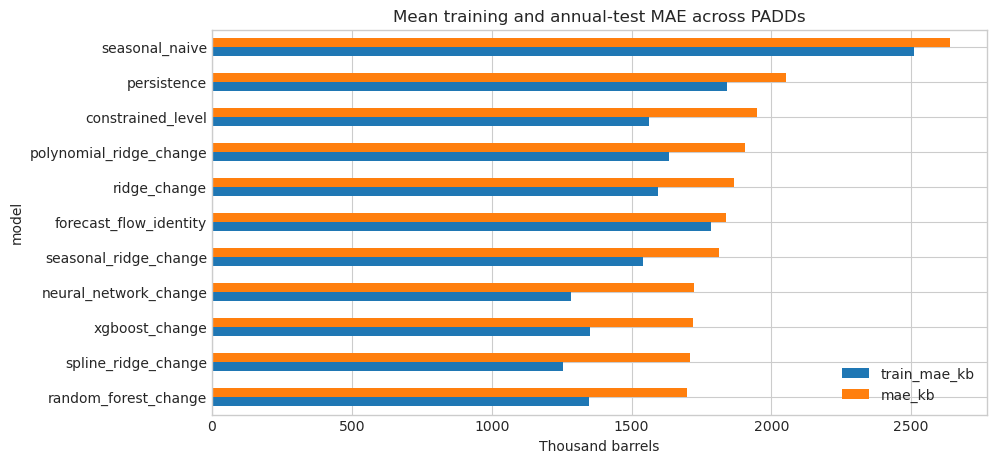

In [28]:
display(tables['selected_models'])
cv = tables['padd_model_metrics'].query("split == 'cv' and model != 'selected_padd_models'")
display(cv.pivot(index='model', columns='padd', values='mae_kb').style.highlight_min(axis=0))
gaps = folds.groupby('model')[['train_mae_kb','mae_kb']].mean().sort_values('mae_kb')
gaps['test_minus_train_kb'] = gaps.mae_kb - gaps.train_mae_kb
display(gaps)
gaps[['train_mae_kb','mae_kb']].plot.barh(figsize=(10,5), title='Mean training and annual-test MAE across PADDs')
plt.xlabel('Thousand barrels'); plt.show()

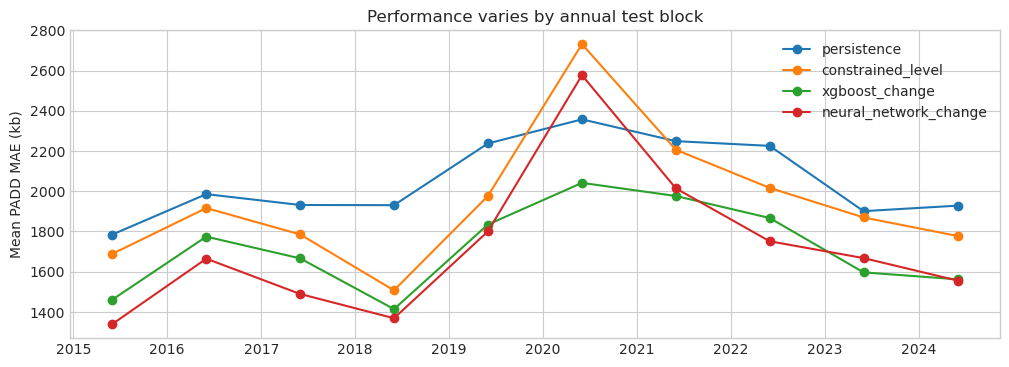

,padd,intercept_kb,stock_lag1,lag_production_kb,lag_demand_kb,lag_imports_kb,lag_exports_kb,lag_net_receipts_kb,lag_adjustments_kb,lag_biofuels_kb
0,1,"9,449.16",0.69,0.41,0.21,0.17,0.86,0.31,0.57,0.00
1,2,"10,203.64",0.65,0.46,0.34,0.05,0.31,0.36,0.23,0.00
2,3,"28,775.52",0.62,0.21,0.20,0.00,0.00,0.26,0.00,0.00
3,4,965.15,0.75,0.21,0.13,0.00,0.00,0.08,0.00,0.00
4,5,"15,487.62",0.48,0.36,0.38,0.33,0.00,0.47,0.10,0.00


In [29]:
fig, ax = plt.subplots(figsize=(12,4))
for name in ['persistence','constrained_level','xgboost_change','neural_network_change']:
    g = folds[folds.model.eq(name)].groupby('test_end').mae_kb.mean()
    ax.plot(pd.to_datetime(g.index), g.values, marker='o', label=name)
ax.set(title='Performance varies by annual test block', ylabel='Mean PADD MAE (kb)')
ax.legend(); plt.show()
display(pd.read_csv(OUTPUT / 'constrained_model_coefficients.csv'))

## 7. Final holdout: does the selected model improve on unchanged stocks?

U.S. errors are computed **after summing all five PADD predictions** for the same month. They are not sums of regional MAEs. Regional errors can offset, so selecting the best regional models need not select the best national combination.

In [30]:
national_scores = tables['us_model_metrics'].query("split == 'holdout'").sort_values('mae_kb')
display(national_scores)
regional_scores = tables['padd_model_metrics'].query("split == 'holdout' and model in ['selected_padd_models','persistence']")
display(regional_scores[['padd','model','mae_kb','rmse_kb','r2']])
selected_mae = national_scores.set_index('model').loc['selected_padd_models','mae_kb']
naive_mae = national_scores.set_index('model').loc['persistence','mae_kb']
improvement = 100*(1-selected_mae/naive_mae)
best_holdout = national_scores.iloc[0]
display(Markdown(f"**Finding:** Selected PADD models produce a U.S. holdout MAE of **{selected_mae:,.0f} kb** "
    f"versus **{naive_mae:,.0f} kb** for unchanged stocks: **{improvement:.1f}% improvement**. "
    f"The lowest observed national holdout MAE belongs to `{best_holdout.model}` "
    f"({best_holdout.mae_kb:,.0f} kb), but that hindsight result is not used to switch the model. "
    "Historical inventory accuracy does not establish a reliable trading edge."))

,model,split,mae_kb,rmse_kb,r2,n
3,forecast_flow_identity,holdout,"3,758.51","5,718.74",0.81,24
19,selected_padd_models,holdout,"4,246.90","5,854.99",0.80,24
21,spline_ridge_change,holdout,"4,509.25","5,755.05",0.81,24
11,random_forest_change,holdout,"4,538.88","6,287.20",0.77,24
15,seasonal_naive,holdout,"4,773.00","5,920.95",0.80,24
5,neural_network_change,holdout,"4,871.68","6,474.18",0.76,24
23,xgboost_change,holdout,"5,144.44","6,906.33",0.72,24
17,seasonal_ridge_change,holdout,"6,717.48","8,365.08",0.59,24
1,constrained_level,holdout,"6,917.32","8,365.01",0.59,24
9,polynomial_ridge_change,holdout,"7,081.62","8,671.07",0.56,24


,padd,model,mae_kb,rmse_kb,r2
7,1,persistence,"3,407.58","4,606.56",0.01
19,1,selected_padd_models,"2,820.81","3,381.15",0.47
31,2,persistence,"3,016.88","3,877.04",0.45
43,2,selected_padd_models,"1,595.56","2,297.23",0.81
55,3,persistence,"3,304.79","4,089.56",0.05
67,3,selected_padd_models,"2,543.87","3,068.79",0.47
79,4,persistence,467.62,645.18,0.45
91,4,selected_padd_models,321.03,468.35,0.71
103,5,persistence,"1,389.08","1,557.95",0.00
115,5,selected_padd_models,"1,058.10","1,295.58",0.31


**Finding:** Selected PADD models produce a U.S. holdout MAE of **4,247 kb** versus **8,469 kb** for unchanged stocks: **49.9% improvement**. The lowest observed national holdout MAE belongs to `forecast_flow_identity` (3,759 kb), but that hindsight result is not used to switch the model. Historical inventory accuracy does not establish a reliable trading edge.

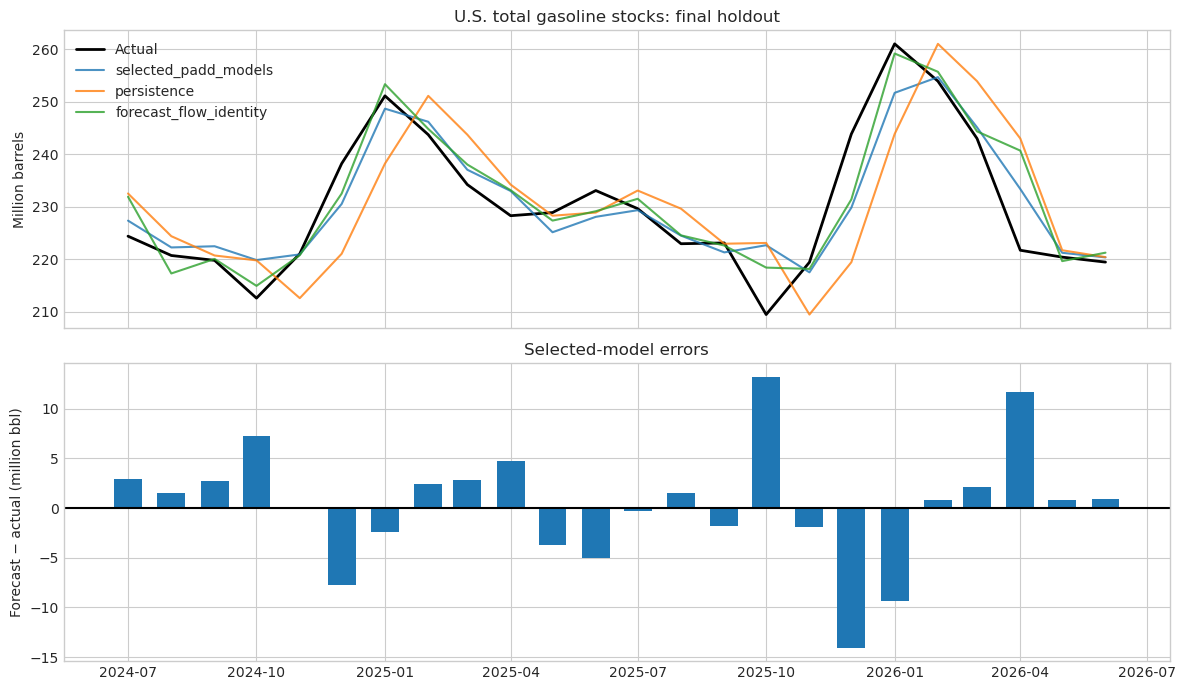

In [31]:
predictions = tables['us_predictions']
holdout = predictions[predictions.split.eq('holdout')]
fig, axes = plt.subplots(2,1,figsize=(12,7),sharex=True)
actual = holdout[holdout.model.eq('selected_padd_models')]
axes[0].plot(actual.month,actual.actual_kb/1000,color='black',label='Actual',linewidth=2)
for name in ['selected_padd_models','persistence','forecast_flow_identity']:
    g = holdout[holdout.model.eq(name)]
    axes[0].plot(g.month,g.predicted_kb/1000,label=name,alpha=.8)
axes[0].set(ylabel='Million barrels',title='U.S. total gasoline stocks: final holdout'); axes[0].legend()
axes[1].bar(actual.month,(actual.predicted_kb-actual.actual_kb)/1000,width=20)
axes[1].axhline(0,color='black'); axes[1].set(ylabel='Forecast − actual (million bbl)',title='Selected-model errors')
plt.tight_layout(); plt.show()

## 8. JODI national context

JODI is a separate source archive, but its U.S. data may share underlying national reporting with EIA. It has no PADD dimension here and is not a model feature or an independently measured regional validation set.

The JODI gasoline category can include aviation gasoline and blending components; country reporting can differ. See the [JODI manual](https://www.jodidata.org/_resources/files/downloads/manuals/jodi-oil-2nd-manual.pdf). We therefore show JODI alongside both EIA finished and total gasoline stocks **without treating their level differences as model errors**. JODI history ends earlier than the fresh EIA scrape; missing recent values stay missing.

Latest JODI archive month: 2026-01-01


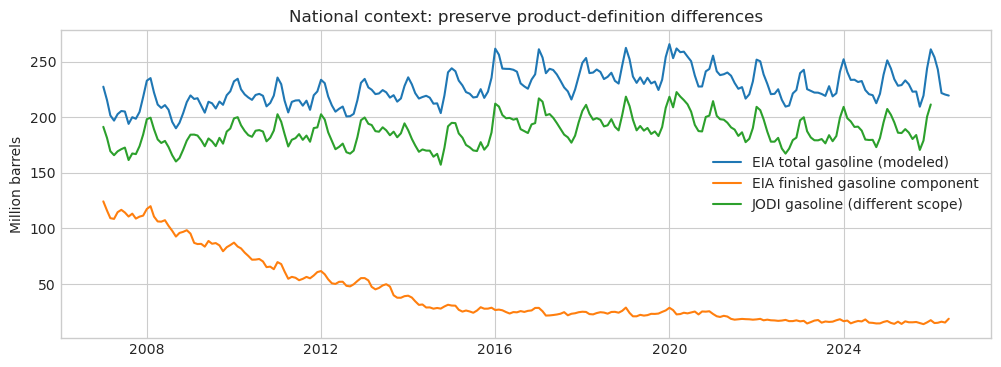

flow_breakdown,month,jodi_CLOSTLV,jodi_IPTRANSF,jodi_PTRANSF,jodi_RECEIPTS,jodi_REFGROUT,jodi_STATDIFF,jodi_STOCKCH,jodi_TOTDEMO,jodi_TOTEXPSB,jodi_TOTIMPSB
223,2025-08-01,"180,371.00","4,820.00",NaN,"29,388.00","250,005.00",-994.00,"-5,777.00","286,743.00","27,459.00","23,218.00"
224,2025-09-01,"183,941.00","7,404.00",NaN,"26,378.00","246,246.00",-108.00,"3,570.00","269,749.00","25,764.00","18,947.00"
225,2025-10-01,"170,531.00","8,533.00",NaN,"30,103.00","239,967.00","2,615.00","-13,410.00","280,716.00","25,997.00","17,315.00"
226,2025-11-01,"178,937.00","8,566.00",NaN,"31,459.00","256,601.00","13,914.00","8,406.00","261,617.00","30,077.00","17,388.00"
227,2025-12-01,"200,492.00","7,385.00",NaN,"29,129.00","277,164.00","5,510.00","21,555.00","273,251.00","34,688.00","21,326.00"
228,2026-01-01,"211,418.00",NaN,NaN,NaN,"276,873.00","1,176.00","10,926.00","242,478.00","34,901.00","12,608.00"


In [32]:
history = tables['us_monthly_model']
jodi = tables['jodi_us_benchmark']
print('Latest JODI archive month:', jodi.month.max().date())
fig, ax = plt.subplots(figsize=(12,4))
for col,label in [('stock_kb','EIA total gasoline (modeled)'),('finished_stock_kb','EIA finished gasoline component'),
                  ('jodi_CLOSTLV','JODI gasoline (different scope)')]:
    ax.plot(history.month,history[col]/1000,label=label)
ax.set(ylabel='Million barrels',title='National context: preserve product-definition differences')
ax.legend(); plt.show()
display(jodi.tail(6))

## 9. Test the full 12-month forecasting procedure

One-step tests update with actual history each month; a 12-month outlook cannot do that. Here we test two disjoint 12-month paths covering the final holdout. Selected model names remain fixed from development CV. Each path refits on history available at its origin, forecasts flows, and feeds predicted stocks and flows forward recursively.

Only **two forecast paths** support this diagnostic. There are just two U.S. errors at each horizon, insufficient for calibrated uncertainty intervals or a strong claim about long-horizon skill.

,padd,mae_kb,rmse_kb,r2,n
0,1,"3,545.29","4,137.75",0.20,24
1,2,"2,044.88","2,419.01",0.79,24
2,3,"2,875.14","3,522.63",0.30,24
3,4,524.78,623.28,0.48,24
4,5,"1,806.31","2,067.70",-0.76,24


,horizon,mae_kb,rmse_kb,r2,n
0,1,"1,645.43","2,109.82",0.35,2
1,2,"3,952.43","3,988.10",-11.65,2
2,3,"3,530.40","3,855.66",-4.39,2
3,4,"12,708.96","12,794.12",-66.00,2
4,5,"10,408.72","10,417.65",-166.06,2
5,6,"3,257.15","3,426.89",-0.48,2
6,7,"6,348.30","8,116.34",-1.68,2
7,8,"5,528.93","6,168.09",-0.46,2
8,9,"5,088.43","5,915.41",-0.81,2
9,10,"8,089.44","8,660.83",-5.92,2


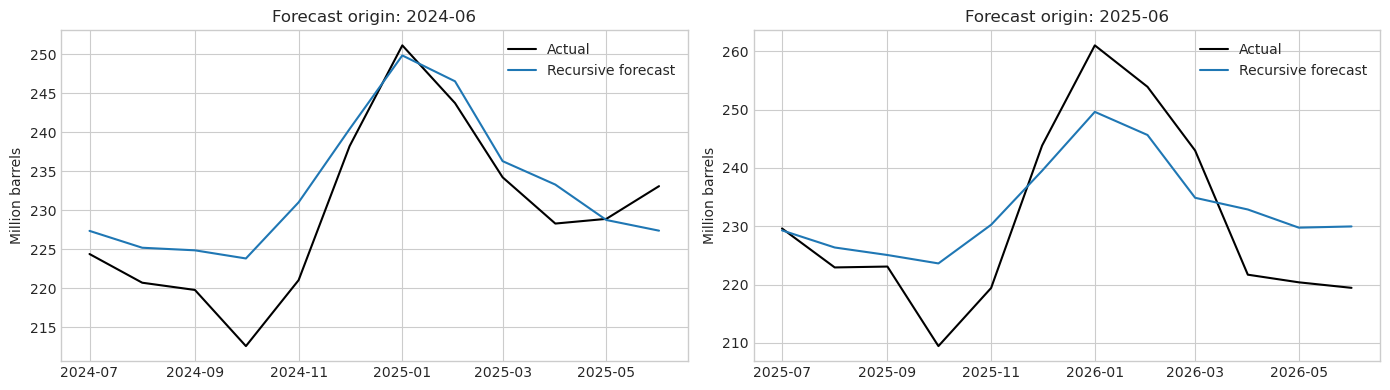

In [33]:
recursive = tables['us_recursive_holdout_predictions']
display(tables['recursive_holdout_metrics'])
display(tables['us_recursive_horizon_metrics'])
fig, axes = plt.subplots(1,2,figsize=(14,4))
for (origin,g),ax in zip(recursive.groupby('origin_month'),axes):
    ax.plot(g.month,g.actual_kb/1000,label='Actual',color='black')
    ax.plot(g.month,g.predicted_kb/1000,label='Recursive forecast')
    ax.set(title=f'Forecast origin: {origin:%Y-%m}',ylabel='Million barrels'); ax.legend()
plt.tight_layout(); plt.show()

## 10. Twelve-month supply-and-demand outlook

Flow forecasts use the same trailing seasonal/trend rule as the backtest. Selected statistical stock models use lagged inputs recursively. The **raw identity stock path** accumulates the projected flow balance. The **selected stock path** need not satisfy that balance exactly, so we export `model_reconciliation_kb = predicted stock change − forecast flow balance`. It is a visible model discrepancy, not a newly observed EIA supply adjustment. The raw identity is left unclipped to expose impossible inventory paths if they arise.

U.S. supply includes net production, imports, net receipts, published adjustments, and biofuel net production; total disposition is domestic product supplied plus exports. Net receipts cancel across PADDs in these data. No price, weather, refinery-outage, policy, or macroeconomic scenarios are assumed beyond the fitted historical paths.

,month,production_kb,imports_kb,demand_kb,exports_kb,adjustments_kb,balance_kb,stock_kb,identity_stock_unclipped_kb,model_reconciliation_kb
0,2026-07-01,"283,420.44","20,924.24","282,345.05","26,409.35","1,221.09","-2,984.03","218,502.68","216,456.97","2,045.71"
1,2026-08-01,"284,033.04","21,119.64","285,183.65","26,615.95","1,116.49","-5,316.83","217,569.18","211,140.14","4,383.33"
2,2026-09-01,"274,602.14","18,129.34","267,452.30","25,445.17",697.01,725.71,"218,035.52","211,865.85",-259.37
3,2026-10-01,"281,101.44","14,102.44","278,402.05","26,921.15","2,089.89","-7,833.03","217,010.43","204,032.82","6,807.94"
4,2026-11-01,"287,758.14","14,597.34","265,572.30","31,358.97","1,659.81","7,257.71","224,152.21","211,290.53",-115.94
5,2026-12-01,"301,164.24","17,356.41","271,929.45","33,203.75","1,688.49","15,230.74","235,946.50","226,521.27","-3,436.44"
6,2027-01-01,"284,511.24","12,709.64","256,063.05","27,418.55","1,437.29","15,323.57","249,027.46","241,844.84","-2,242.62"
7,2027-02-01,"246,669.32","12,753.17","242,057.78","23,186.43",915.95,"-4,762.51","246,005.40","237,082.33","1,740.45"
8,2027-03-01,"274,655.04","15,028.24","276,444.45","26,285.95","1,564.09","-11,306.43","236,374.90","225,775.90","1,675.93"
9,2027-04-01,"263,685.74","19,544.14","267,680.10","23,653.77",550.81,"-7,368.49","229,385.32","218,407.42",378.91


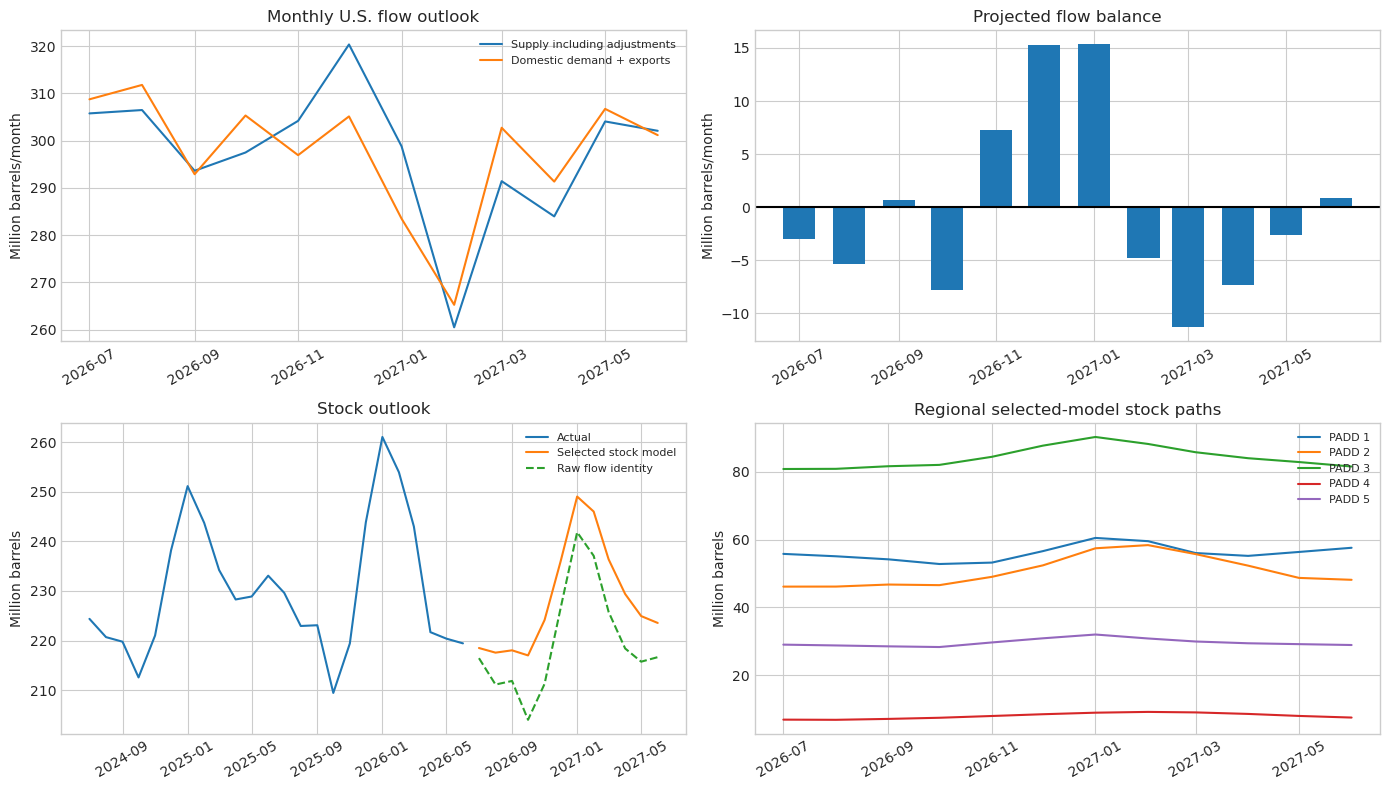

In [34]:
outlook = tables['us_forecast_12m']
display(outlook[['month','production_kb','imports_kb','demand_kb','exports_kb','adjustments_kb',
                 'balance_kb','stock_kb','identity_stock_unclipped_kb','model_reconciliation_kb']])
fig, axes = plt.subplots(2,2,figsize=(14,8))
for c,label in [('supply_kb','Supply including adjustments'),('total_demand_kb','Domestic demand + exports')]:
    axes[0,0].plot(outlook.month,outlook[c]/1000,label=label)
axes[0,0].set(title='Monthly U.S. flow outlook',ylabel='Million barrels/month'); axes[0,0].legend(fontsize=8)
axes[0,1].bar(outlook.month,outlook.balance_kb/1000,width=20)
axes[0,1].axhline(0,color='black'); axes[0,1].set(title='Projected flow balance',ylabel='Million barrels/month')
recent = history.tail(24)
axes[1,0].plot(recent.month,recent.stock_kb/1000,label='Actual')
axes[1,0].plot(outlook.month,outlook.stock_kb/1000,label='Selected stock model')
axes[1,0].plot(outlook.month,outlook.identity_stock_unclipped_kb/1000,label='Raw flow identity',linestyle='--')
axes[1,0].set(title='Stock outlook',ylabel='Million barrels'); axes[1,0].legend(fontsize=8)
for p,g in tables['padd_forecast_12m'].groupby('padd'):
    axes[1,1].plot(g.month,g.stock_kb/1000,label=f'PADD {p}')
axes[1,1].set(title='Regional selected-model stock paths',ylabel='Million barrels'); axes[1,1].legend(fontsize=8)
for ax in axes.flat: ax.tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.show()

## 11. What to conclude, and how to reproduce

The balance reconstruction is sound, but its small residual is not evidence of predictive power. For this total-gasoline run, the selected regional models reduce national holdout MAE from about 8,469 kb to 4,247 kb (49.9%); holdout R² is about 0.80. The forecast-flow identity has still lower holdout MAE, but it was not chosen retrospectively to replace the development-selected models. These results concern a larger, different inventory boundary and are not directly comparable to the old finished-only error levels.

The 12-month paths are **conditional point forecasts**, with limited recursive validation and no calibrated intervals. The target and all balance flows now cover total motor gasoline. Constituent stocks reconcile to the independent total series within 1 kb. The complete balance has January 2026 stock-level/reporting discrepancies of +66 kb (PADD 1), -43 kb (PADD 3), and -81 kb (PADD 5); other monthly residuals are at rounding/reporting scale. These are retained rather than forced to zero. JODI comparisons retain their differing product scope. Sparse-flow zero assumptions, historical revisions, reporting changes, and publication lags remain limitations.

**Reproduce from this directory:**

```bash
python -m pip install -r requirements.txt
python us_snd_model.py                  # archived sources, no download
python us_snd_model.py --refresh-data   # refresh EIA and snapshot JODI from DuckDB
python -m pytest -q
```

Use **Run All** to regenerate the analysis and tables in this notebook. `model_output/` contains regional/national histories, every fold prediction, fold and holdout metrics, chosen models, regression coefficients, fitting warnings, recursive holdout results, the 12-month forecasts, metadata, and serialized final selected models. `data/` preserves downloaded inputs and provenance. The shared database is read-only throughout.

**Single-notebook workflow:** All implementation code is included above, from source preparation to exported results. No local Python module is imported. Use Run All to execute the analysis with the accompanying `data/` folder; readers can view the saved tables and charts without executing anything.

### Reproducibility checks included in the notebook

Check source hashes, finished versus total gasoline stocks, forecast timing, national aggregation, and separation of development targets from the final evaluation period. These checks run on the same inputs and outputs just used for the analysis.

In [35]:
for entry in json.loads((HERE/'data/source_manifest.json').read_text()):
    source_bytes=(HERE/'data/raw'/entry['source_file']).read_bytes()
    assert hashlib.sha256(source_bytes).hexdigest()==entry['sha256']
np.testing.assert_allclose(panel.stock_kb, panel.finished_stock_kb + panel.blending_stock_kb, atol=1, rtol=0)
np.testing.assert_allclose(panel.production_kb, panel.finished_production_kb-panel.blending_net_inputs_kb)
check_history=panel[panel.padd.eq(1)].iloc[:40].copy()
before=supervised(check_history)
check_history.loc[check_history.index[-1],FLOWS+['stock_kb']]+=100000
changed=supervised(check_history)
feature_columns=[c for c in before if c not in ['actual_kb','delta_kb']]
pd.testing.assert_frame_equal(before[feature_columns],changed[feature_columns])
np.testing.assert_allclose(tables['us_forecast_12m'].stock_kb,
    tables['padd_forecast_12m'].groupby('month').stock_kb.sum())
print('Source integrity, stock scope, target-month isolation, and aggregation checks passed.')

Source integrity, stock scope, target-month isolation, and aggregation checks passed.


In [36]:
display(pd.Series(metadata, name='Configuration'))
print('Saved result files:')
for path in sorted(OUTPUT.iterdir()):
    print(path.name)
assert not tables['padd_predictions'].duplicated(['padd','month','model','split']).any()
assert tables['padd_forecast_12m'].groupby('month').padd.nunique().eq(5).all()
assert len(outlook) == 12
print('Notebook checks passed.')

product                 Total motor gasoline: finished motor gasoline ...
stock_units                                 thousand barrels at month end
flow_units                            thousand barrels per calendar month
equation                S[t] = S[t-1] + (finished refinery/blender net...
data_start                                                     2007-01-01
data_end                                                       2026-06-01
cv                      10 expanding folds, 12 test months each; final...
holdout_start                                                  2024-07-01
forecast_timing         One month after latest observed EIA month; con...
selection               Lowest pooled development CV MAE per PADD incl...
flow_forecast           Last 60 months, daily rates, linear trend and ...
components              Flows sum finished and blending components; pr...
forecast_stock_floor                                                    0
uncertainty             Point forecast

Saved result files:
candidate_models.json
constrained_model_coefficients.csv
fit_warnings.csv
fitted_models.joblib
fold_metrics.csv
jodi_us_benchmark.csv
latest_forecast.csv
model_metadata.json
padd_forecast_12m.csv
padd_model_metrics.csv
padd_monthly_model.csv
padd_predictions.csv
recursive_holdout_metrics.csv
recursive_holdout_predictions.csv
selected_models.csv
us_forecast_12m.csv
us_model_metrics.csv
us_monthly_model.csv
us_predictions.csv
us_recursive_holdout_predictions.csv
us_recursive_horizon_metrics.csv
Notebook checks passed.
